<div style="background: linear-gradient(135deg, #e9f2fb 0%, #f7fbff 100%); padding: 18px 20px; border: 1px solid #d5e3f0; border-radius: 10px; text-align: center;">
  <div style="font-size: 32px; font-weight: 700; color: #1f3b57; letter-spacing: 0.2px;">NX-414 Brain-like Computation and Intelligence</div>
</div>


<div style="text-align: center; font-size: 21px; font-weight: 600; color: #36536b; margin-top: 6px;">Project Notebook — Spring 2026</div>


<div style="text-align: center; color: #4f6478; font-size: 16px; margin-bottom: 10px;">Brain–Model Alignment Across Neural Recording Modalities</div>
<div style="text-align: center; color: #6b7280; font-size: 13px;">Prepared by: Abdulkadir Gokce</div>

---


# Group Information

Fill in this section at the top of your notebook and report.

- **Group member 1:** Full name, SCIPER number, email address  
- **Group member 2:** Full name, SCIPER number, email address  
- **Group member 3 (if applicable):** Full name, SCIPER number, email address  

---

# What You Must Submit

Submit the following files:

1. **One Jupyter notebook** containing your full analysis.
2. **Any supporting Python scripts** needed to run the notebook.
3. **Figures that are part of your notebook answers** should be embedded and rendered in notebook Markdown.
4. **One PDF report** of **up to 2 pages**, **excluding references**, with **no appendix**.
5. **One zip archive** named exactly as:

```text
nx414_{SCIPER1}_{SCIPER2}_{SCIPER3}.zip
```

If your group has fewer than three members, reduce the number of `_SCIPER` fields accordingly.

## Submission Rules

- **Clear all notebook outputs before submission.**
- If outputs are not cleared, we will clear them ourselves and grade the cleaned notebook.
- Submit only the code required to reproduce your results.
- **Do not submit model weights.**
- **Do not submit CSV files or other large derived result dumps.**
- Keep the archive lightweight and reproducible.
- For the **final notebook**, any figure you want to present as part of your scientific argument should be **embedded in Markdown with accompanying interpretation**, rather than left as a raw cell output with no explanation.

Failure to follow these instructions may reduce your final grade.

## Use of LLMs

You may use LLM-based tools to help you write code, debug, or improve explanations. However, you remain fully responsible for the **correctness**, **quality**, and **clarity** of everything you submit, including both the notebook and the report.

In particular:

- check that any generated code actually runs and does what you claim it does,
- verify that any scientific statement or interpretation is correct,
- make sure the final writing sounds like a clear academic report written for this course,
- avoid vague, overly polished, or context-free text,
- avoid fancy wording or unnecessarily complex sentences that do not add clarity.

If you use an LLM, revise the output so that your submission reads naturally, is specific to your actual results, and does not look like generic generated text.

Failure to do so may result in **a point deduction**.

## Expected scope

Because this project spans roughly **three weeks** and counts for **30% of the final course grade**, the expected output is closer to a **compact course project** than to a one-week homework notebook. Your submission should therefore read like a small empirical study: it should be clearly structured, contain short written interpretations throughout, compare alternatives systematically, and end with a coherent synthesis of your main findings.

A strong notebook will not only run end-to-end, but will also explain **why** each analysis is being performed, what each metric is meant to capture, and what the results imply about the strengths and limitations of the models and datasets.

At the same time, **some parts of the project are intentionally left a bit loose**. This is by design: beyond implementing the required core analyses, you are expected to make reasonable scientific choices, justify them clearly, and show some ingenuity in how you explore the data and compare models.

## Suggested 3-week pacing

Use the notebook structure below to organize your work over the three weeks.

- **Week 1:** complete **Section 0** and **Section 1**. Understand the datasets, verify stimulus matching, inspect the processed responses, and start the visualization and reliability analyses.
- **Week 2:** complete the required analyses in **Section 2**. In this section, you must complete both the representational and predictive parts of the project. Begin **Section 3** by brainstorming possible extensions and sketching out a plan for your chosen extension.
- **Week 3:** complete **Section 3**, polish the notebook, select the strongest figures, and write the 2-page report.


---

# 0. Introduction and Setup

## 0.1 Project goal

In this project, you will study how neural responses from different recording modalities align with features extracted from two vision models. More specifically, you will work in the standard **brain–model alignment** setting: a model processes an image, a candidate internal layer is selected, and that representation is compared to measured neural responses using representational and predictive metrics.

The notebook is organized around four sections:

- **Section 0:** introduction, setup, and understanding the provided resources.
- **Section 1:** dataset inspection, visualization, and noise ceiling estimation.
- **Section 2:** brain–model alignment through both representational metrics and predictive linear models.
- **Section 3:** an open-ended extension beyond the baseline pipeline.

## 0.2 Why task-optimized models?

Task-optimized neural networks are among the most useful current **in-silico models of sensory cortex**. The central idea is simple: instead of hand-designing a model to mimic every biological detail, we optimize a model to perform a meaningful visual task and then ask whether its internal representations resemble those found in the brain. This approach has been highly influential because models trained to solve vision tasks often develop representations that predict activity along the visual hierarchy surprisingly well.

These models are useful scientifically because they provide **testable computational hypotheses**. If a model layer predicts neural responses well, that does not mean the brain literally implements the same mechanism, but it does suggest that the layer may encode information in a similar format or at a similar level of abstraction. Brain–model alignment is therefore a way to ask not just whether a model is accurate on a task, but whether it organizes visual information in a brain-relevant way.

## 0.3 Why compare multiple modalities?

A single recording modality gives only a partial view of neural computation. In this project, you will work with **electrophysiology, EEG, and fMRI**, which differ in temporal resolution, spatial resolution, and what exactly is measured. Looking across modalities helps you see which conclusions are robust and which depend on the measurement scale.

## 0.4 Learning goals

By the end of this project, you should be able to:

- inspect and summarize neural datasets from multiple modalities,
- visualize neural signals and data quality,
- implement and compare **two noise ceiling estimators**,
- implement **RSA** and **unbiased linear CKA**,
- fit **linear encoding models** from model features to neural responses,
- compare alignment across **models, layers, ROIs, and metrics**,
- interpret what each alignment metric captures,
- design and evaluate one meaningful extension beyond the baseline pipeline.

A strong submission should therefore demonstrate both **technical correctness** and **scientific reasoning**: beyond obtaining scores, you should be able to explain why a dataset is noisy, why one layer may outperform another, and why representational and predictive metrics sometimes disagree.

## 0.5 Provided data

All main data are stored in `/shared/NX-414/data/`.

### Background: processed data derivatives

The files provided for this project are **not raw neural recordings**. They are already processed, analysis-ready derivatives produced with modality-appropriate pipelines. This is important scientifically: many of your results will depend not only on the model features, but also on preprocessing choices such as repetition averaging, denoising, response-window selection, voxel/channel filtering, and how reliability is estimated.

We performed the preprocessing for you because these pipelines often require substantial modality-specific expertise, time, and compute.

At a high level, the datasets used here were prepared as follows:

- **TVSD (macaque electrophysiology)** — normalized multi-unit responses from ventral-stream areas. Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, low-reliability channels were excluded, and repeated test responses were averaged for evaluation.
- **THINGS-EEG2 (human EEG)** — source EEG responses resampled to **100 Hz**. Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.
- **NSD (human fMRI)** — **b3 single-trial beta estimates** in `func1pt8mm` space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.

You are **not** expected to re-run the full preprocessing pipelines. You **are** expected to understand what kinds of neural quantities you are analyzing, what has already been averaged or denoised, and how these choices affect interpretation.

### Main neural datasets

- **`tvsd.h5`** — macaque electrophysiology from **2 monkeys**, with **22,248 train** and **100 test** stimuli, covering **V1, V4, and IT**.
- **`things_eeg2.h5`** — human EEG from **10 subjects**, with **16,540 train** and **200 test** stimuli, with region groupings such as **occipital**, **parietal**, **temporal**, **frontal**, **central**, **occipital_parietal**, and **whole_brain**.
- **`nsd_func1pt8mm_individualROIs.h5`** — human fMRI from **8 subjects**, with roughly **9,000 train** and **1,000 test** stimuli per subject, across multiple visual ROIs.

### Additional files

- `things_eeg2-test_reps.h5`  
  EEG test responses **with repetitions and without averaging**.  
  Use this file to implement and compare **two noise ceiling estimators**.

- `nsd-subj01-ncsnr-{lh,rh}.mgh`  
  Surface-based NSD reliability values for `subj-01` on **fsaverage**.  
  Use these to visualize cortical reliability and convert **ncsnr** into **noise ceiling**.

### Neural response shapes

- **TVSD:** `(n_stimuli, n_units)`
- **EEG2:** `(n_stimuli, n_channels, n_timepoints)`
- **NSD:** `(n_stimuli, n_voxels)`

For EEG, the time axis contains **80 time points** sampled at **100 Hz**, covering **0.0 s to 0.8 s**.

### Noise ceilings

Noise ceilings are stored per target:

- per neuron for **TVSD**,
- per channel × time point for **EEG2**,
- per voxel for **NSD**.

They are stored as **percent reliability**.  
To convert them to the range `[0, 1]`, divide by `100`.

In this project, the provided noise ceilings are mainly intended for **predictive metrics** such as **Pearson correlation** and **explained variance**. They reflect the reliability of the neural responses and therefore define an upper bound on how well any model can predict those responses.

When you compute predictive metrics, you should apply a noise ceiling correction to account for this upper bound. The standard idea is simple: divide the raw predictive score by the corresponding noise ceiling value for that target.

The provided noise ceilings are defined for **explained variance**. If you want to apply the same logic to **Pearson correlation**, first convert the explained-variance ceiling into a correlation ceiling by taking the element-wise square root, and then divide the raw correlation by that quantity. For a more detailed discussion of noise ceiling correction, see van Bree et al. (2025).

You may therefore report both **raw** and **noise-ceiling-corrected** predictive scores where appropriate.


For example, if the provided ceiling is an explained-variance reliability estimate, you can compute a noise-corrected Pearson correlation as:

```python
r_nc = r / np.sqrt(ev_ceiling)
```

where `r` is the raw Pearson correlation and `ev_ceiling` is the explained-variance ceiling expressed on the range `[0, 1]`.

By contrast, **RSA** and **CKA** should typically be reported as **raw values** in this project. Noise ceilings for representational similarity metrics require a different methodology and are **not** provided here.


Do **not** apply this correction directly to **RSA** or **CKA**.

### Stimulus identifiers

- **TVSD / EEG2:** byte strings such as `b'aardvark/aardvark_01b.jpg'`
- **NSD:** integer stimulus IDs

## 0.6 Model features

All extracted features are stored in `/shared/NX-414/extracted_features/`.

The feature files contain **internal activations extracted from multiple candidate layers** while the models process the same images shown in the neural experiments. You can think of each layer as a representation matrix of shape roughly **stimuli × features**. These layer-wise representations are what you will compare to the brain using RSA, CKA, and encoding models.

Feature extractions across models were made tractable by projecting activations to **30,000 dimensions** using a random projection. The provided feature files follow that same idea. In practice, this means you can treat the feature vectors as compact surrogates for the original activations while still performing meaningful alignment analyses.

### Model A: `adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0`

- Architecture: **ResNet-152**
- Pretraining: ImageNet + adversarial fine-tuning
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

### Model B: `Qwen3-VL-2B-Instruct`

- Architecture: **vision-language transformer**
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

For both models, layers have been projected to **30,000 dimensions** using random projections.

### Feature extraction note

For this project, feature extraction has already been done for you. Your job is therefore not to run the vision models on raw images, but to understand **which layer** to use, how to match feature rows to neural stimuli, and what different layers reveal about representational hierarchy.

### Important note for NSD

For NSD, the feature files contain features for **all 73,000 images**, but each subject saw only a subset (~9,000).  
You must therefore select feature rows using the subject-specific NSD stimulus IDs.

## 0.7 Matching features to neural responses

You must match neural responses and features through the stimulus IDs.

### THINGS-based datasets: TVSD and EEG2

For these datasets, both neural IDs and feature IDs are byte strings. Matching should therefore be exact.

### NSD

For NSD, both sides use integer IDs. The feature file contains all 73,000 stimuli, while each subject has only a subset. Use the subject-specific NSD stimulus IDs to select the corresponding feature rows.

### Recommended procedure

```python
feat_ids = feature_file['ids'][:]
id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
```

To make HDF5 reads efficient:

1. build the index array,
2. sort indices before reading,
3. load only the required rows,
4. restore the original order.

## 0.8 General analysis rules

### Train/test discipline

Do **not** use the test split for model selection or hyperparameter tuning. Use a validation split or cross-validation within the training data.

### EEG targets

For EEG, you may either:

- flatten the targets to `(n_stimuli, n_channels * n_timepoints)`, or
- fit separate models per channel × time point.

Either choice is acceptable, but you must explain your decision clearly.

### Predictive metrics

Report the following predictive metrics where appropriate:

- `pearsonr`
- `pearsonr_nc`
- `explained_variance`
- `explained_variance_nc`

The provided EEG signals are not filtered like the other datasets. As a result, some low-reliability channels or time points can produce unstable predictive scores. When averaging predictive metrics over EEG targets, apply an on-the-fly filter such as **noise ceiling < 0.1**.

### Representational metrics

Also report:

- `RSA`
- `CKA`
- `encoding-RSA`
- `encoding-CKA`

Encoding RSA/CKA is a hybrid metric where you compute RSA or CKA between the predicted neural responses (from the linear encoding model) and the actual neural responses, instead of just comparing model activation directly. This can help you understand whether the linear encoding model captures the representational geometry of the neural data, beyond just predicting individual response values. You can refer to Conwell et al. (2024) for more details on this approach. 

Use only the test split for computing representational metrics.

Do **not** noise-correct RSA or CKA using the predictive-metric procedure.

## 0.9 Setup and data loading

Your notebook should begin with a short introduction, clear imports, utility functions, and a brief verification that the provided files are correctly organized and matched.

**Section 0 is required but not graded separately.** It is treated as setup for the rest of the project. Missing or incorrect setup may reduce scores in later sections if it affects correctness or reproducibility.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Import the required packages.
- Define utility functions.
- Load metadata for all datasets.
- Inspect the structure of each `.h5` file.
- Load feature metadata for both models.
- Verify that feature IDs and neural stimulus IDs match.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Dataset and feature overview:** one compact table or printed summary covering all neural datasets and both feature sets.
2. **Stimulus-matching verification:** explicit checks or assertions showing that stimulus matching works for THINGS-based datasets and for NSD.
3. **Short structural summary:** a short written note describing the main structural differences across datasets.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Questions you should answer</div>

- How many stimuli are available in each dataset?
- What is the shape of the neural response tensor in each dataset?
- Which datasets contain subjects, ROIs, repetitions, channels, or time points?
- What are the feature dimensionalities across layers?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

# TODO

In [ ]:
# TODO: imports
# TODO: define paths
# TODO: inspect dataset structure
# TODO: verify stimulus matching

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
import h5py
import nibabel as nib
from nilearn import plotting as nlplt
from sklearn.linear_model import Ridge # TODO: be careful with sklearn
from sklearn import metrics
import torch
import warnings
warnings.filterwarnings('ignore')
# helper functions
from utils import *

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("All imports OK")

All imports OK


---

# 1. Inspection, Visualization, and Noise Ceiling Estimates

This section is about understanding the data before doing model comparison. By the end of it, you should have a clear sense of how each modality is organized, which signals appear reliable, and how the provided reliability estimates relate to your own computations.

## 1.1 Inspect the datasets

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Inspect the content and axis meaning of TVSD, EEG2, and NSD.
- Identify where subject IDs, ROI labels, time axes, stimulus IDs, and noise ceilings are stored.
- State clearly what each axis means for each response array.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **TVSD structure table**
2. **EEG2 structure table**
3. **NSD structure table**

Each table must list the array name, array shape, and the meaning of each axis.

In [ ]:
# TODO: inspect TVSD
# TODO: inspect EEG2
# TODO: inspect NSD
# TODO: summarize axis meaning

In [2]:
from pathlib import Path

DATA_DIR    = Path("/shared/NX-414/data")
FEAT_DIR    = Path("/shared/NX-414/extracted_features")

# --- Neural data files ---
TVSD_PATH      = DATA_DIR / "tvsd.h5"
EEG_PATH       = DATA_DIR / "things_eeg2.h5"
EEG_REPS_PATH  = DATA_DIR / "things_eeg2-test_reps.h5"
NSD_PATH       = DATA_DIR / "nsd_func1pt8mm_individualROIs.h5"
NSD_NCSNR_LH   = DATA_DIR / "nsd-subj01-ncsnr-lh.mgh"
NSD_NCSNR_RH   = DATA_DIR / "nsd-subj01-ncsnr-rh.mgh"

# --- Model feature directories ---
MODEL_A_NAME = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B_NAME = "Qwen3-VL-2B-Instruct"

FEAT_A_THINGS = FEAT_DIR / MODEL_A_NAME / "things_stimuli.h5"
FEAT_A_NSD    = FEAT_DIR / MODEL_A_NAME / "nsd_stimuli.h5"
FEAT_B_THINGS = FEAT_DIR / MODEL_B_NAME / "things_stimuli.h5"
FEAT_B_NSD    = FEAT_DIR / MODEL_B_NAME / "nsd_stimuli.h5"

# Sanity check — all files should exist
all_paths = {
    "tvsd":          TVSD_PATH,
    "eeg":           EEG_PATH,
    "eeg_reps":      EEG_REPS_PATH,
    "nsd":           NSD_PATH,
    "nsd_ncsnr_lh":  NSD_NCSNR_LH,
    "nsd_ncsnr_rh":  NSD_NCSNR_RH,
    "feat_A_things": FEAT_A_THINGS,
    "feat_A_nsd":    FEAT_A_NSD,
    "feat_B_things": FEAT_B_THINGS,
    "feat_B_nsd":    FEAT_B_NSD,
}
for name, p in all_paths.items():
    status = "✓" if p.exists() else "✗ MISSING"
    print(f"  {status}  {name}: {p}")

  ✓  tvsd: /shared/NX-414/data/tvsd.h5
  ✓  eeg: /shared/NX-414/data/things_eeg2.h5
  ✓  eeg_reps: /shared/NX-414/data/things_eeg2-test_reps.h5
  ✓  nsd: /shared/NX-414/data/nsd_func1pt8mm_individualROIs.h5
  ✓  nsd_ncsnr_lh: /shared/NX-414/data/nsd-subj01-ncsnr-lh.mgh
  ✓  nsd_ncsnr_rh: /shared/NX-414/data/nsd-subj01-ncsnr-rh.mgh
  ✓  feat_A_things: /shared/NX-414/extracted_features/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/things_stimuli.h5
  ✓  feat_A_nsd: /shared/NX-414/extracted_features/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/nsd_stimuli.h5
  ✓  feat_B_things: /shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/things_stimuli.h5
  ✓  feat_B_nsd: /shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/nsd_stimuli.h5


#### TVSD dataset structure

In [3]:
print("=" * 55)
print("TVSD (macaque electrophysiology)")
print("=" * 55)
inspect_h5(TVSD_PATH, max_depth = 4) # adjusted to 4 to confirm shapes from "Neural response shapes" section

TVSD (macaque electrophysiology)
  <group> noise_ceilings/
  <group> noise_ceilings/monkeyF/
  [noise_ceilings/monkeyF/IT]  shape=(241,)  dtype=float64
  [noise_ceilings/monkeyF/V1]  shape=(462,)  dtype=float64
  [noise_ceilings/monkeyF/V4]  shape=(139,)  dtype=float64
  <group> noise_ceilings/monkeyN/
  [noise_ceilings/monkeyN/IT]  shape=(178,)  dtype=float64
  [noise_ceilings/monkeyN/V1]  shape=(437,)  dtype=float64
  [noise_ceilings/monkeyN/V4]  shape=(247,)  dtype=float64
  <group> test/
  <group> test/neural_data/
  <group> test/neural_data/monkeyF/
  [test/neural_data/monkeyF/IT]  shape=(100, 241)  dtype=float64
  [test/neural_data/monkeyF/V1]  shape=(100, 462)  dtype=float64
  [test/neural_data/monkeyF/V4]  shape=(100, 139)  dtype=float64
  <group> test/neural_data/monkeyN/
  [test/neural_data/monkeyN/IT]  shape=(100, 178)  dtype=float64
  [test/neural_data/monkeyN/V1]  shape=(100, 437)  dtype=float64
  [test/neural_data/monkeyN/V4]  shape=(100, 247)  dtype=float64
  [test/stimu

**Explanation:**

- The TVSD dataset is organized by monkey (monkeyF and N) and brain region (IT, V1, V4).
- Neural responses are stored as 2D arrays of shape (n_stimuli, n_units)
- Rows correspond positionally to stimulus_ids such that we can match each recording a certain stimulus
- Noise ceilings are stored per unit / neuron as 1D arrays of shape (n_units,); this matches the second axis of the neural data
- dataset is pre-split into 22,248 training and 100 test stimuli.

**Some notes:**
- although the splits between the datasets are not equal, resplitting to get a more reliable final performance estimate on the test set is probably not advisable as splitting requires domain knowledge and deep knowledge of the dataset to not leak information from train to test (could be achieved by us) but also noise ceilings would have to be recomputed, etc. Probably the test set is carefully chosen by the authors. Further, other papers probably use the proposed split so we'd lose comparibility.
- When we do cross - validation, we must ensure that no stimulus indices appear in both the train and validation folds!

Check whether reponses are averaged repetitions or the same stimulus_ids appear multiple times per participant

In [4]:
with h5py.File(TVSD_PATH, "r") as f:
    train_ids = f["train/stimulus_ids"][:]

n_total = len(train_ids)
n_unique = len(set(train_ids))
print(f"Total: {n_total}, Unique: {n_unique}")

Total: 22248, Unique: 22248


#### THINGS-EEG (human EEG) dataset structure

In [5]:
print("\n" + "=" * 55)
print("THINGS-EEG2 (human EEG)")
print("=" * 55)
inspect_h5(EEG_PATH, max_depth = 4) # again depth = 4 for more details


THINGS-EEG2 (human EEG)
  <group> noise_ceilings/
  <group> noise_ceilings/sub-01/
  [noise_ceilings/sub-01/central]  shape=(14, 80)  dtype=float64
  [noise_ceilings/sub-01/frontal]  shape=(21, 80)  dtype=float64
  [noise_ceilings/sub-01/occipital]  shape=(3, 80)  dtype=float64
  [noise_ceilings/sub-01/occipital_parietal]  shape=(17, 80)  dtype=float64
  [noise_ceilings/sub-01/parietal]  shape=(14, 80)  dtype=float64
  [noise_ceilings/sub-01/temporal]  shape=(6, 80)  dtype=float64
  [noise_ceilings/sub-01/whole_brain]  shape=(63, 80)  dtype=float64
  <group> noise_ceilings/sub-02/
  [noise_ceilings/sub-02/central]  shape=(14, 80)  dtype=float64
  [noise_ceilings/sub-02/frontal]  shape=(21, 80)  dtype=float64
  [noise_ceilings/sub-02/occipital]  shape=(3, 80)  dtype=float64
  [noise_ceilings/sub-02/occipital_parietal]  shape=(17, 80)  dtype=float64
  [noise_ceilings/sub-02/parietal]  shape=(14, 80)  dtype=float64
  [noise_ceilings/sub-02/temporal]  shape=(6, 80)  dtype=float64
  [noise

Check whether reponses are averaged repetitions or the same stimulus_ids appear multiple times per participant

In [6]:
with h5py.File(EEG_PATH, "r") as f:
    train_ids = f["train/stimulus_ids"][:]

n_total = len(train_ids)
n_unique = len(set(train_ids))
print(f"Total: {n_total}, Unique: {n_unique}")

Total: 16540, Unique: 16540


Data already averaged across the 4 repetitions

Stimulus IDs serve as a shared key between the neural recordings and the model feature files. Since we may only extract model features for a subset of all available images, we cannot rely on row indices alone and must match explicitly through the IDs. This is especially critical for NSD, where the feature file contains activations for all 73,000 images but each subject only saw roughly 9,000 of them.

**Explanation:**

- The THINGS-EEG2 dataset is organized by subject (sub-01 through sub-10) and brain region (occipital, parietal, temporal, frontal, central, occipital_parietal, whole_brain).
- Neural responses are stored as 3D arrays of shape (n_stimuli, n_channels, n_timepoints), where n_timepoints=80 covering 0–0.8s at 100Hz.
- Rows correspond positionally to stimulus_ids, which are shared across all subjects — all 10 subjects saw the exact same stimuli in the same order.
- Noise ceilings are stored per channel×timepoint as 2D arrays of shape (n_channels, 80), reflecting that reliability varies across both space and time. They are computed via split-half correlation on the 80 test repetitions.
- There are two noise ceiling groups: noise_ceilings/ computed from test repetitions (80 reps, reliable) and noise_ceilings_train/ computed from training repetitions (4 reps, noisier).
- The dataset is pre-split into 16,540 training and 200 test stimuli. Training responses are already averaged across the 4 repetitions (confirmed: all stimulus IDs are unique).

**Some notes:**

- have to discuss whether to use this noisy noise ceiling (haha) when using cross-validation. Claude was unsure whether it makes sense, thus, read papers maybe or ask TA

#### NSD (human fMRI) dataset

In [7]:
print("\n" + "=" * 55)
print("NSD (human fMRI)")
print("=" * 55)
inspect_h5(NSD_PATH, max_depth=3)


NSD (human fMRI)
  <group> noise_ceiling_full/
  [noise_ceiling_full/subj01]  shape=(81, 104, 83)  dtype=float32
  [noise_ceiling_full/subj02]  shape=(82, 106, 84)  dtype=float32
  [noise_ceiling_full/subj03]  shape=(81, 106, 82)  dtype=float32
  [noise_ceiling_full/subj04]  shape=(85, 99, 80)  dtype=float32
  [noise_ceiling_full/subj05]  shape=(79, 97, 78)  dtype=float32
  [noise_ceiling_full/subj06]  shape=(85, 113, 83)  dtype=float32
  [noise_ceiling_full/subj07]  shape=(78, 95, 81)  dtype=float32
  [noise_ceiling_full/subj08]  shape=(80, 103, 78)  dtype=float32
  <group> noise_ceilings/
  <group> noise_ceilings/subj01/
  [noise_ceilings/subj01/EBA]  shape=(2078,)  dtype=float32
  [noise_ceilings/subj01/FBA-1]  shape=(339,)  dtype=float32
  [noise_ceilings/subj01/FBA-2]  shape=(255,)  dtype=float32
  [noise_ceilings/subj01/FFA-1]  shape=(423,)  dtype=float32
  [noise_ceilings/subj01/FFA-2]  shape=(173,)  dtype=float32
  [noise_ceilings/subj01/OFA]  shape=(283,)  dtype=float32
  [no

In [8]:
with h5py.File(NSD_PATH, "r") as f:
    mask_nc = f["roi_labels_nc/subj01/V1v"][:]
    nc      = f["noise_ceilings/subj01/V1v"][:]

print(f"roi_labels_nc True count: {mask_nc.sum()}")
print(f"noise_ceilings length:    {len(nc)}")

roi_labels_nc True count: 570
noise_ceilings length:    570


**Explanation:**
- The NSD dataset is organized by subject (subj01–subj08) and ROI. Unlike EEG2, each subject has
  their own stimulus IDs since different subjects saw different subsets of the 73,000 COCO images.
- Neural responses are stored as 2D arrays of shape `(n_stimuli, n_voxels)` per subject per ROI,
  where rows correspond positionally to that subject's stimulus IDs.
- Not all subjects completed the same number of sessions, so the number of stimuli varies across subjects.

**Understanding the spatial structure:**
- `roi_labels/` stores 3D boolean masks marking which voxels belong to each anatomical ROI.
- `roi_labels_nc/` stores the same kind of mask but only for voxels actually included in the 1D
  neural data and noise ceiling arrays. This is the critical mapping — without it you cannot know
  which voxels correspond to which entries in the 1D arrays.
- `noise_ceilings/` stores noise ceiling values as 1D arrays corresponding exactly to the `True`
  positions in `roi_labels_nc/`. We verified this: the length of `noise_ceilings/subj01/V1v`
  matches exactly the number of `True` values in `roi_labels_nc/subj01/V1v`.

**Some notes:**
- Stimulus IDs are integers (COCO image IDs) and differ per subject — we must use each subject's own stimulus IDs to select the correct rows from the feature file.
- Some ROIs may have zero voxels for certain subjects (e.g. subj02/FBA-1), and should be skipped when encountered.

### Verify stimulus matching: THINGS-based datasets (TVSD & EEG2)

(THINGS = image dataset used for visual stimuli in those two experiments/datasets)

In [9]:
# ---- TVSD ----
with h5py.File(TVSD_PATH, "r") as f:
    tvsd_train_ids = f["train/stimulus_ids"][:]
    tvsd_test_ids  = f["test/stimulus_ids"][:]

tvsd_feat_idx = build_id_index(FEAT_A_THINGS)

missing_train = [x for x in tvsd_train_ids if x not in tvsd_feat_idx]
missing_test  = [x for x in tvsd_test_ids  if x not in tvsd_feat_idx]

assert len(missing_train) == 0, f"TVSD train: {len(missing_train)} IDs missing"
assert len(missing_test)  == 0, f"TVSD test:  {len(missing_test)}  IDs missing"
print(f"TVSD ✓  train={len(tvsd_train_ids):,}  test={len(tvsd_test_ids):,}  all matched")

# ---- EEG2 ----
with h5py.File(EEG_PATH, "r") as f:
    eeg_train_ids = f["train/stimulus_ids"][:]
    eeg_test_ids  = f["test/stimulus_ids"][:]

missing_train = [x for x in eeg_train_ids if x not in tvsd_feat_idx]
missing_test  = [x for x in eeg_test_ids  if x not in tvsd_feat_idx]

assert len(missing_train) == 0, f"EEG train: {len(missing_train)} IDs missing"
assert len(missing_test)  == 0, f"EEG test:  {len(missing_test)}  IDs missing"
print(f"EEG2 ✓  train={len(eeg_train_ids):,}  test={len(eeg_test_ids):,}  all matched")

TVSD ✓  train=22,248  test=100  all matched
EEG2 ✓  train=16,540  test=200  all matched


<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.1</strong><br>Explain the main differences between the three modalities in terms of what is being measured and how the data are organized.</div>

The three datasets differ fundamentally in what they measure and how they are organized.

**TVSD** records multi-unit spiking activity (MUA) from macaque visual cortex using chronically 
implanted Utah arrays — 1,024 microelectrodes spread across V1, V4, and IT in two animals [[2]](#papale2025). 
MUA aggregates spiking from multiple neurons near each electrode tip, sampled at 30 kHz. This 
gives exceptional temporal resolution: response windows of 25–125ms for V1, 50–150ms for V4, 
and 75–175ms for IT already reflect the known latency gradient along the visual hierarchy. 
Within the implanted regions, spatial resolution is on the order of hundreds of micrometers. 
The data are organized as 2D arrays (n_stimuli × n_units) per monkey per region, with no time 
axis since responses are already averaged within the analysis window.

**THINGS-EEG2** records scalp EEG from 10 human subjects using non-invasive electrode caps [[3]](#gifford2022). 
EEG provides full cortical coverage but poor spatial resolution due to volume conduction: the 
electrical signal spreads through skull and tissue before reaching the electrodes, blurring the 
spatial origin of the signal. Deep brain structures contribute minimally. Temporal resolution is 
good — the raw signal was sampled at 1 kHz and downsampled to 100 Hz for the provided data, 
though the 100 Hz is a preprocessing choice rather than a hardware limit. The data are organized 
as 3D arrays (n_stimuli × n_channels × n_timepoints), preserving the full temporal dynamics. 
Regions are defined anatomically by source location (occipital, parietal, temporal, frontal) 
rather than by functional visual area as in TVSD.

**NSD** records BOLD fMRI responses from 8 human subjects at 7T with 1.8mm voxel resolution [[4]](#allen2022). 
BOLD is a hemodynamic signal reflecting changes in the ratio of oxygenated to deoxygenated 
hemoglobin that follow neural activity with a substantial delay. The hemodynamic response peaks 
roughly 5–6 seconds after the neural event [[1]](#liao2002), and the brief initial dip in oxygenated 
hemoglobin that immediately follows neural firing is generally too small to reliably detect, 
meaning the measurable signal is dominated by the delayed overshoot of oxygenated blood flow. 
The 7T field strength was chosen specifically to maximize SNR over standard 3T scanners. Data 
are organized as 2D arrays (n_stimuli × n_voxels) per subject per ROI, where ROIs correspond 
to well-characterized functional visual areas (V1, V2, V3, hV4, FFA, PPA, etc.). Each subject 
has a different number of voxels per ROI due to individual brain anatomy, and stimulus IDs 
differ per subject since each saw a different subset of the 73,000 COCO images.

In summary, TVSD offers the highest temporal and spatial precision but is invasive, limited to 
macaques, and covers only a few targeted regions. EEG2 captures full-brain temporal dynamics 
non-invasively in humans but with poor spatial resolution. NSD provides the richest spatial 
picture of the human visual system at the cost of temporal resolution and an indirect 
hemodynamic signal. Together, the three modalities offer complementary views of the visual 
system that no single recording technique could provide alone.

**Data organization:**

TVSD is organized by monkey (monkeyF, monkeyN) and region (V1, V4, IT). Neural responses are 
stored as 2D arrays of shape `(n_stimuli, n_units)`, where the stimulus axis is aligned 
positionally to the stimulus ID array of shape `(n_stimuli,)`, meaning row $i$ of the neural 
data corresponds to stimulus $i$ of the ID array. Noise ceilings are stored as 1D arrays of 
shape `(n_units,)`, matching the second axis of the neural data exactly. The dataset is 
pre-split into 22,248 training and 100 test stimuli, shared across both monkeys.

THINGS-EEG2 is organized by subject (sub-01 through sub-10) and anatomical region (occipital, 
parietal, temporal, frontal, central, occipital_parietal, whole_brain). Neural responses are 
stored as 3D arrays of shape `(n_stimuli, n_channels, n_timepoints)`, where n_timepoints = 80 
covering 0–0.8s at 100 Hz. Noise ceilings are stored as 2D arrays of shape 
`(n_channels, n_timepoints)`, reflecting that reliability varies across both space and time. 
Two sets of noise ceilings are provided: `noise_ceilings/` computed from the 80 test 
repetitions and `noise_ceilings_train/` computed from the 4 training repetitions. Training 
responses are already averaged across repetitions (confirmed by all 16,540 training stimulus 
IDs being unique). The stimulus ID arrays of shape `(n_stimuli,)` are shared across all subjects 
since every subject saw the same images in the same order. The dataset is pre-split into 16,540 
training and 200 test stimuli.

NSD is organized by subject (subj01 through subj08) and ROI. Neural responses are stored as 2D 
arrays of shape `(n_stimuli, n_voxels)` per subject per ROI, positionally aligned to that 
subject's stimulus ID array. The number of stimuli and voxels varies across subjects due to 
differences in the number of completed sessions and individual brain anatomy. Two spatial 
structures are important here. `roi_labels/` stores 3D boolean masks of the full brain volume 
marking the anatomical extent of each ROI. `roi_labels_nc/` stores a refined version of this 
mask containing only the voxels that pass a reliability criterion. These are exactly the 
voxels included in the 1D neural data and noise ceiling arrays, confirmed by matching counts. 
Without `roi_labels_nc/` it is not possible to map the 1D arrays back to brain space. Noise 
ceilings are stored as 1D arrays of shape `(n_voxels,)` per subject per ROI, matching the 
second axis of the neural data. Stimulus IDs are integers (COCO image IDs) and differ per 
subject since each subject saw a different subset of the full 73,000-image pool.

## References

<a id="liao2002"></a>[1] C.-H. Liao, K. J. Worsley, J.-B. Poline, J. A. D. Aston, G. H. Duncan, and A. C. Evans, "Estimating the delay of the fMRI response," *NeuroImage*, vol. 16, no. 3, pp. 593–606, 2002.

<a id="papale2025"></a>[2] P. Papale, F. Wang, M. W. Self, and P. R. Roelfsema, "An extensive dataset of spiking activity to reveal the syntax of the ventral stream," *Neuron*, vol. 113, no. 4, pp. 539–553, 2025.

<a id="gifford2022"></a>[3] A. T. Gifford, K. Dwivedi, G. Roig, and R. M. Cichy, "A large and rich EEG dataset for modeling human visual object recognition," *NeuroImage*, vol. 264, p. 119754, 2022.

<a id="allen2022"></a>[4] E. J. Allen, G. St-Yves, Y. Wu, J. L. Breedlove, J. S. Prince, L. T. Dowdle, M. Nau, B. Caron, F. Pestilli, I. Charest, et al., "A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence," *Nature Neuroscience*, vol. 25, no. 1, pp. 116–126, 2022.

---

## 1.2 Visualize EEG signals

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Plot example EEG responses for several stimuli and channels.
- Plot average responses over time for at least one subject and one ROI.
- Visualize the provided EEG noise ceilings over channels and time.

To detect potentially dead or degraded channels, we compute the variance of each 0.8s epoch 
across the 80 timepoints, giving one quality value per (stimulus, channel) pair. We then 
average these values within blocks of 200 consecutive stimuli to reduce noise and produce a 
readable summary. The resulting heatmap has stimulus blocks on the y-axis (a proxy for time 
in the experiment) and channels on the x-axis. A uniformly dark column indicates a dead 
channel throughout the recording, while a column that transitions from bright to dark suggests 
a channel that degraded at some point during the experiment.

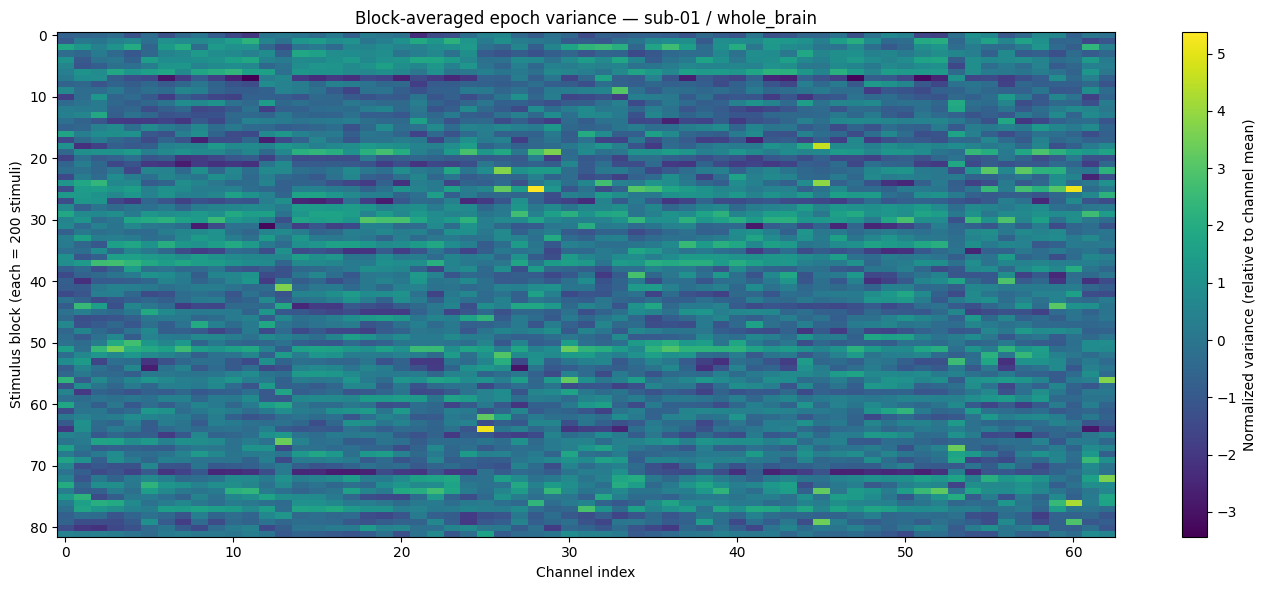

In [10]:
# ---- Block-averaged channel quality heatmap ----
BLOCK_SIZE = 200
SUBJECT    = "sub-01"
ROI        = "whole_brain"

with h5py.File(EEG_PATH, "r") as f:
    # shape: (16540, n_channels, 80)
    train_data = f[f"train/neural_data/{SUBJECT}/{ROI}"][:]

n_stimuli, n_channels, n_timepoints = train_data.shape
n_blocks = n_stimuli // BLOCK_SIZE

# For each stimulus, compute variance over the 80 timepoints -> (n_stimuli, n_channels)
epoch_var = train_data.var(axis=2)

# Average within blocks -> (n_blocks, n_channels)
epoch_var_blocked = epoch_var[:n_blocks * BLOCK_SIZE].reshape(n_blocks, BLOCK_SIZE, n_channels).mean(axis=1)
# Z-score each channel across blocks
channel_mean = epoch_var_blocked.mean(axis=0)
channel_std  = epoch_var_blocked.std(axis=0)
epoch_var_blocked_norm = (epoch_var_blocked - channel_mean) / (channel_std + 1e-8)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(epoch_var_blocked_norm , aspect="auto", cmap="viridis",
               interpolation="nearest")
ax.set_xlabel("Channel index")
ax.set_ylabel(f"Stimulus block (each = {BLOCK_SIZE} stimuli)")
ax.set_title(f"Block-averaged epoch variance — {SUBJECT} / {ROI}")
plt.colorbar(im, ax=ax, label="Normalized variance (relative to channel mean)")
plt.tight_layout()
plt.show()

In [11]:
import ipywidgets as widgets
from IPython.display import display

# ---- Block-averaged channel quality heatmap ----
BLOCK_SIZE = 200
SUBJECT    = "sub-01"
ROI        = "whole_brain"

with h5py.File(EEG_PATH, "r") as f:
    train_data = f[f"train/neural_data/{SUBJECT}/{ROI}"][:]

n_stimuli, n_channels, n_timepoints = train_data.shape
n_blocks = n_stimuli // BLOCK_SIZE

# For each stimulus, compute variance over the 80 timepoints -> (n_stimuli, n_channels)
epoch_var = train_data.var(axis=2)

# Average within blocks -> (n_blocks, n_channels)
epoch_var_blocked = epoch_var[:n_blocks * BLOCK_SIZE].reshape(n_blocks, BLOCK_SIZE, n_channels).mean(axis=1)

# Z-score each channel across blocks
channel_mean = epoch_var_blocked.mean(axis=0)
channel_std  = epoch_var_blocked.std(axis=0)
epoch_var_blocked_norm = (epoch_var_blocked - channel_mean) / (channel_std + 1e-8)

def plot_threshold(threshold):
    fig, ax = plt.subplots(figsize=(14, 6))
    mask = (epoch_var_blocked_norm < threshold).astype(float)
    im = ax.imshow(mask, aspect="auto", cmap="RdYlGn_r",
                   interpolation="nearest", vmin=0, vmax=1)
    ax.set_xlabel("Channel index")
    ax.set_ylabel(f"Stimulus block (each = {BLOCK_SIZE} stimuli)")
    ax.set_title(f"Dead channel detection (threshold={threshold:.2f}) — {SUBJECT} / {ROI}")
    plt.colorbar(im, ax=ax, label="0 = OK, 1 = dead/degraded")
    plt.tight_layout()
    plt.show()

slider = widgets.FloatSlider(
    value=-1.5, min=-3.0, max=0.0, step=0.1,
    description="Threshold:",
    continuous_update=False,
    style={"description_width": "initial"}
)

widgets.interact(plot_threshold, threshold=slider)

interactive(children=(FloatSlider(value=-1.5, continuous_update=False, description='Threshold:', max=0.0, min=…

<function __main__.plot_threshold(threshold)>

In [14]:
import ipywidgets as widgets
from IPython.display import display

n_examples = 5

# Compute normalization statistics across ALL stimuli (do this once)
with h5py.File(EEG_PATH, "r") as f:
    all_data = f[f"train/neural_data/{SUBJECT}/{ROI}"][:]

# Variance per stimulus -> (n_stimuli, n_channels)
epoch_var_all = all_data.var(axis=2)

# Statistics across all stimuli per channel
stim_mean = epoch_var_all.mean(axis=0)  # (n_channels,)
stim_std  = epoch_var_all.std(axis=0)   # (n_channels,)

def plot_channel_block_detail(block_idx, channel_idx, stim_offset):
    start = block_idx * BLOCK_SIZE
    end   = start + BLOCK_SIZE
    
    # Load this block
    data_block = all_data[start:end]  # (BLOCK_SIZE, n_channels, 80)
    
    # Variance per stimulus -> (BLOCK_SIZE, n_channels)
    var_block = data_block.var(axis=2)
    
    # Z-score using global statistics
    var_block_norm = (var_block - stim_mean) / (stim_std + 1e-8)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Left: heatmap of all stimuli in this block x all channels
    im = axes[0].imshow(var_block_norm, aspect="auto", cmap="viridis",
                        interpolation="nearest")
    axes[0].axvline(x=channel_idx, color="red", linewidth=1.5, 
                    label=f"Channel {channel_idx}")
    # Horizontal bars showing which stimuli are plotted on the right
    axes[0].axhline(y=stim_offset,             color="orange", linewidth=1.5, linestyle="--")
    axes[0].axhline(y=stim_offset + n_examples - 1, color="orange", linewidth=1.5, 
                    linestyle="--", label=f"Stimuli shown on right")
    axes[0].set_xlabel("Channel index")
    axes[0].set_ylabel("Stimulus index within block")
    axes[0].set_title(f"Z-scored variance — block {block_idx} (stimuli {start}–{end})")
    axes[0].legend(fontsize=8)
    plt.colorbar(im, ax=axes[0], label="Z-scored variance")
    
    # Right: time courses of selected channel for n_examples stimuli
    time_axis  = np.linspace(0, 0.8, n_timepoints)
    for i in range(n_examples):
        stim_in_block = stim_offset + i
        axes[1].plot(time_axis, data_block[stim_in_block, channel_idx, :],
                     alpha=0.7, label=f"Stimulus {start + stim_in_block}")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title(f"Time courses — channel {channel_idx}, block {block_idx}")
    axes[1].legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

n_examples = 5

block_slider = widgets.IntSlider(
    value=0, min=0, max=n_blocks - 1, step=1,
    description="Block index:",
    continuous_update=False,
    style={"description_width": "initial"}
)
channel_slider = widgets.IntSlider(
    value=0, min=0, max=n_channels - 1, step=1,
    description="Channel index:",
    continuous_update=False,
    style={"description_width": "initial"}
)
stim_slider = widgets.IntSlider(
    value=0, min=0, max=BLOCK_SIZE - n_examples, step=1,
    description="Stimulus offset:",
    continuous_update=False,
    style={"description_width": "initial"}
)

widgets.interact(plot_channel_block_detail, 
                 block_idx=block_slider, 
                 channel_idx=channel_slider,
                 stim_offset=stim_slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Block index:', max=81, style=Sl…

<function __main__.plot_channel_block_detail(block_idx, channel_idx, stim_offset)>

Log scale

In [18]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.colors as mcolors

n_examples = 5

# Compute normalization statistics across ALL stimuli (do this once)
with h5py.File(EEG_PATH, "r") as f:
    all_data = f[f"train/neural_data/{SUBJECT}/{ROI}"][:]

# Variance per stimulus -> (n_stimuli, n_channels)
epoch_var_all = all_data.var(axis=2)

# Statistics across all stimuli per channel
stim_mean = epoch_var_all.mean(axis=0)  # (n_channels,)
stim_std  = epoch_var_all.std(axis=0)   # (n_channels,)

def plot_channel_block_detail(block_idx, channel_idx, stim_offset):
    start = block_idx * BLOCK_SIZE
    end   = start + BLOCK_SIZE
    
    # Load this block
    data_block = all_data[start:end]  # (BLOCK_SIZE, n_channels, 80)
    
    # Variance per stimulus -> (BLOCK_SIZE, n_channels)
    var_block = data_block.var(axis=2)
    
    # Z-score using global statistics
    var_block_norm = (var_block - stim_mean) / (stim_std + 1e-8)

    print(f"Z-scores for shown stimuli (channel {channel_idx}):")
    for i in range(n_examples):
        stim_in_block = stim_offset + i
        z = var_block_norm[stim_in_block, channel_idx]
        print(f"  Stimulus {start + stim_in_block}: z = {z:.2f}")
        
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Left: heatmap of all stimuli in this block x all channels
    im = axes[0].imshow(var_block_norm, aspect="auto", cmap="viridis",
                    interpolation="nearest",
                    norm=mcolors.SymLogNorm(linthresh=1))
    axes[0].axvline(x=channel_idx, color="red", linewidth=1.5, 
                    label=f"Channel {channel_idx}")
    # Horizontal bars showing which stimuli are plotted on the right
    axes[0].axhline(y=stim_offset,             color="orange", linewidth=1.5, linestyle="--")
    axes[0].axhline(y=stim_offset + n_examples - 1, color="orange", linewidth=1.5, 
                    linestyle="--", label=f"Stimuli shown on right")
    axes[0].set_xlabel("Channel index")
    axes[0].set_ylabel("Stimulus index within block")
    axes[0].set_title(f"Z-scored variance — block {block_idx} (stimuli {start}–{end})")
    axes[0].legend(fontsize=8)
    plt.colorbar(im, ax=axes[0], label="Z-scored variance")
    
    # Right: time courses of selected channel for n_examples stimuli
    time_axis  = np.linspace(0, 0.8, n_timepoints)
    for i in range(n_examples):
        stim_in_block = stim_offset + i
        axes[1].plot(time_axis, data_block[stim_in_block, channel_idx, :],
                     alpha=0.7, label=f"Stimulus {start + stim_in_block}")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title(f"Time courses — channel {channel_idx}, block {block_idx}")
    axes[1].legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

n_examples = 5

block_slider = widgets.IntSlider(
    value=0, min=0, max=n_blocks - 1, step=1,
    description="Block index:",
    continuous_update=False,
    style={"description_width": "initial"}
)
channel_slider = widgets.IntSlider(
    value=0, min=0, max=n_channels - 1, step=1,
    description="Channel index:",
    continuous_update=False,
    style={"description_width": "initial"}
)
stim_slider = widgets.IntSlider(
    value=0, min=0, max=BLOCK_SIZE - n_examples, step=1,
    description="Stimulus offset:",
    continuous_update=False,
    style={"description_width": "initial"}
)

widgets.interact(plot_channel_block_detail, 
                 block_idx=block_slider, 
                 channel_idx=channel_slider,
                 stim_offset=stim_slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Block index:', max=81, style=Sl…

<function __main__.plot_channel_block_detail(block_idx, channel_idx, stim_offset)>

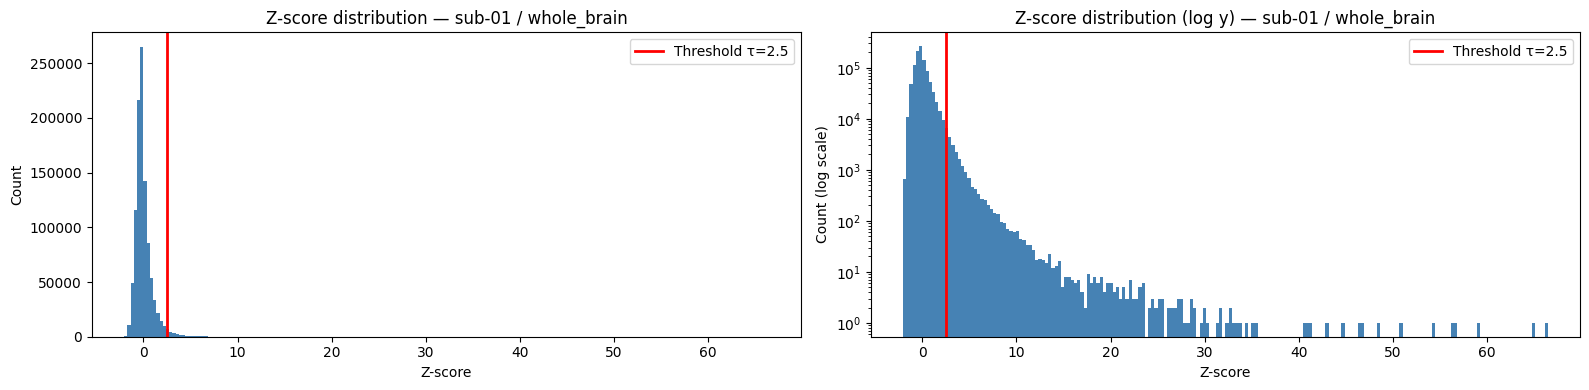

Flagged: 22025 / 1042020 (2.11%)


In [33]:
# Z-score all stimuli using global statistics
epoch_var_norm_all = (epoch_var_all - stim_mean) / (stim_std + 1e-8)  # (n_stimuli, n_channels)

THRESHOLD = 2.5

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Linear y-scale
axes[0].hist(epoch_var_norm_all.flatten(), bins=200, color="steelblue", edgecolor="none")
axes[0].axvline(x=THRESHOLD, color="red", linewidth=2, label=f"Threshold τ={THRESHOLD}")
axes[0].set_xlabel("Z-score")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Z-score distribution — {SUBJECT} / {ROI}")
axes[0].legend()

# Log y-scale
axes[1].hist(epoch_var_norm_all.flatten(), bins=200, color="steelblue", edgecolor="none")
axes[1].axvline(x=THRESHOLD, color="red", linewidth=2, label=f"Threshold τ={THRESHOLD}")
axes[1].set_yscale("log")
axes[1].set_xlabel("Z-score")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title(f"Z-score distribution (log y) — {SUBJECT} / {ROI}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print fraction flagged
n_flagged = (epoch_var_norm_all > THRESHOLD).sum()
n_total   = epoch_var_norm_all.size
print(f"Flagged: {n_flagged} / {n_total} ({100 * n_flagged / n_total:.2f}%)")

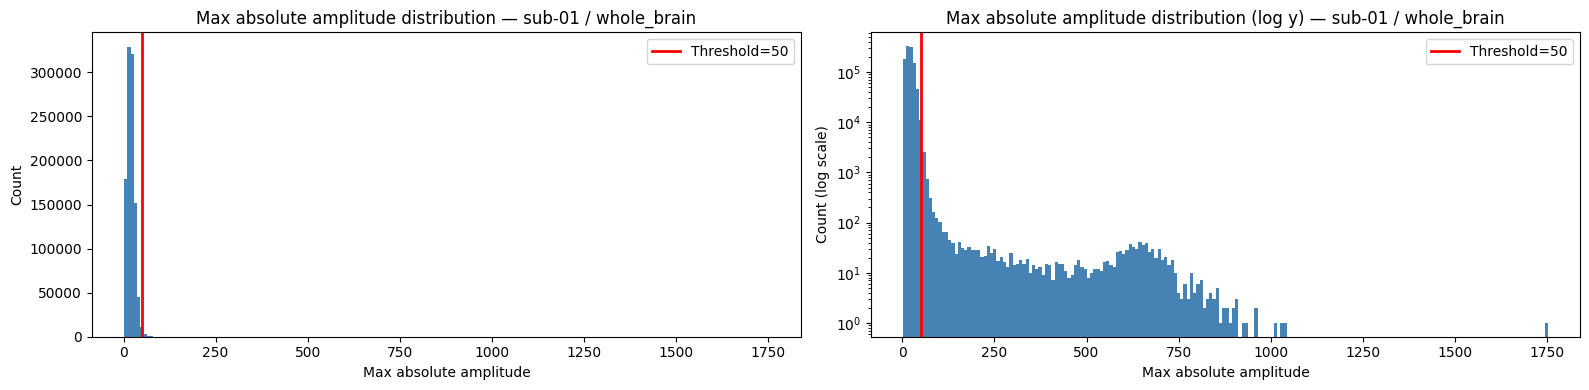

Flagged: 9270 / 1042020 (0.89%)


In [31]:
# Max absolute value per stimulus per channel
max_abs_all = np.abs(all_data).max(axis=2)  # (n_stimuli, n_channels)

THRESHOLD_ABS = 50

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Linear y-scale
axes[0].hist(max_abs_all.flatten(), bins=200, color="steelblue", edgecolor="none")
axes[0].axvline(x=THRESHOLD_ABS, color="red", linewidth=2, label=f"Threshold={THRESHOLD_ABS}")
axes[0].set_xlabel("Max absolute amplitude")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Max absolute amplitude distribution — {SUBJECT} / {ROI}")
axes[0].legend()

# Log y-scale
axes[1].hist(max_abs_all.flatten(), bins=200, color="steelblue", edgecolor="none")
axes[1].axvline(x=THRESHOLD_ABS, color="red", linewidth=2, label=f"Threshold={THRESHOLD_ABS}")
axes[1].set_yscale("log")
axes[1].set_xlabel("Max absolute amplitude")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title(f"Max absolute amplitude distribution (log y) — {SUBJECT} / {ROI}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print fraction flagged
n_flagged = (max_abs_all > THRESHOLD_ABS).sum()
n_total   = max_abs_all.size
print(f"Flagged: {n_flagged} / {n_total} ({100 * n_flagged / n_total:.2f}%)")

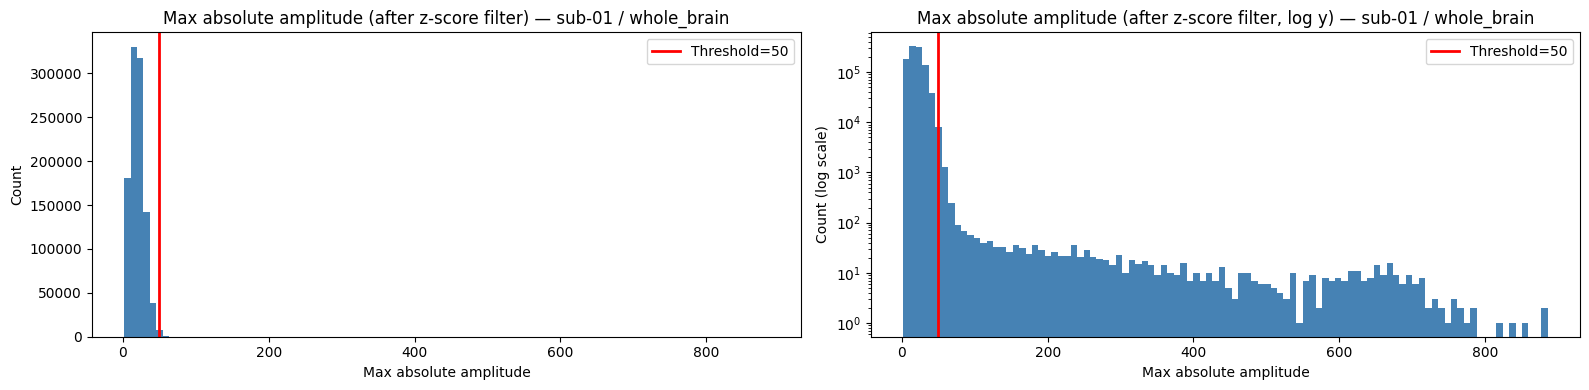

After z-score filter: 1,019,995 / 1,042,020 pairs remaining
Additionally flagged by amplitude: 5520 (0.54% of remaining)


In [24]:
# Apply z-score filter first
zscore_mask = epoch_var_norm_all > THRESHOLD  # (n_stimuli, n_channels), True = flagged

# Get max abs values for unflagged stimuli only
max_abs_filtered = max_abs_all.copy()
max_abs_filtered[zscore_mask] = np.nan  # mask out z-score flagged pairs

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Linear y-scale
axes[0].hist(max_abs_filtered[~zscore_mask].flatten(), bins=100, 
             color="steelblue", edgecolor="none")
axes[0].axvline(x=THRESHOLD_ABS, color="red", linewidth=2, 
                label=f"Threshold={THRESHOLD_ABS}")
axes[0].set_xlabel("Max absolute amplitude")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Max absolute amplitude (after z-score filter) — {SUBJECT} / {ROI}")
axes[0].legend()

# Log y-scale
axes[1].hist(max_abs_filtered[~zscore_mask].flatten(), bins=100, 
             color="steelblue", edgecolor="none")
axes[1].axvline(x=THRESHOLD_ABS, color="red", linewidth=2, 
                label=f"Threshold={THRESHOLD_ABS}")
axes[1].set_yscale("log")
axes[1].set_xlabel("Max absolute amplitude")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title(f"Max absolute amplitude (after z-score filter, log y) — {SUBJECT} / {ROI}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print fractions
n_remaining = (~zscore_mask).sum()
n_flagged_abs = (max_abs_filtered[~zscore_mask] > THRESHOLD_ABS).sum()
print(f"After z-score filter: {n_remaining:,} / {max_abs_all.size:,} pairs remaining")
print(f"Additionally flagged by amplitude: {n_flagged_abs} ({100 * n_flagged_abs / n_remaining:.2f}% of remaining)")

In [32]:
# Combined quality mask
# True = flagged as bad (either high variance or extreme amplitude)
quality_mask = zscore_mask | (max_abs_all > THRESHOLD_ABS)  # (n_stimuli, n_channels)

n_flagged_total = quality_mask.sum()
n_total         = quality_mask.size
n_flagged_z     = zscore_mask.sum()
n_flagged_amp   = (max_abs_all > THRESHOLD_ABS).sum()
n_flagged_both  = (zscore_mask & (max_abs_all > THRESHOLD_ABS)).sum()

print(f"Total stimulus-channel pairs:        {n_total:,}")
print(f"Flagged by z-score (τ={THRESHOLD}):    {n_flagged_z:,} ({100 * n_flagged_z / n_total:.2f}%)")
print(f"Flagged by amplitude (>{THRESHOLD_ABS}): {n_flagged_amp:,} ({100 * n_flagged_amp / n_total:.2f}%)")
print(f"Flagged by both:                     {n_flagged_both:,} ({100 * n_flagged_both / n_total:.2f}%)")
print(f"Flagged by either (total):           {n_flagged_total:,} ({100 * n_flagged_total / n_total:.2f}%)")
print(f"Remaining clean pairs:               {n_total - n_flagged_total:,} ({100 * (1 - n_flagged_total / n_total):.2f}%)")

Total stimulus-channel pairs:        1,042,020
Flagged by z-score (τ=2.5):    22,025 (2.11%)
Flagged by amplitude (>50): 9,270 (0.89%)
Flagged by both:                     3,750 (0.36%)
Flagged by either (total):           27,545 (2.64%)
Remaining clean pairs:               1,014,475 (97.36%)


### EEG data quality assessment

Before analyzing the EEG responses, we first assessed the recording quality. We expected three 
types of problematic channels: dead channels with near-zero variance producing no meaningful 
signal, channels with unusually high variance caused by movement artifacts or equipment noise, 
and channels that drift over time showing a slowly changing baseline. A drifting channel also 
produces high variance since the drift itself contributes to signal variability. One limitation 
of variance-based detection is that mean shifts — where a channel is displaced to a very 
different amplitude but remains stable — are not directly detectable, which motivated our 
second amplitude-based filter described below.

With 16,540 training stimuli per subject, inspecting every stimulus-channel pair individually 
is not feasible. We therefore grouped stimuli into blocks of 200 consecutive stimuli, using 
block index as a proxy for time in the experiment. For each stimulus we computed the variance 
over the 80 timepoints of the 0.8s epoch, giving one quality value per stimulus-channel pair, 
which was then averaged within each block to produce a matrix of shape 
$(n_{\text{blocks}}, n_{\text{channels}})$.

To make differences visible across channels with very different natural amplitudes, we applied 
z-score normalization per channel using statistics computed across all stimuli. This was 
necessary because channels vary considerably in amplitude — some consistently show values in 
the $\pm 30$ range while others stay within $\pm 5$. Using raw variance would make the 
colorscale dominated by high-amplitude channels, hiding degradation in quieter ones. The 
z-score instead shows relative changes within each channel compared to its own baseline.

The blocked heatmap provided a useful first overview but turned out to be somewhat hard to 
interpret on its own, as averaging over 200 stimuli smooths out individual artifacts. We 
therefore built an interactive tool to inspect individual blocks at full stimulus resolution 
using a symmetric log scale to handle the wide dynamic range of z-score values. This revealed 
that certain channels showed recurring problems, particularly channels 13 and 53. These 
appeared as mostly flat columns in the heatmap with occasional extreme values.

Inspecting the actual time courses confirmed this: stimulus 7144 (sub-01, channel 13) showed 
a signal starting at $-200$, drifting to $-100$, then jumping to $+600$ within a single 0.8s 
epoch. Stimulus 7140 showed similar behavior, jumping between $-600$, $+100$ and $-550$.
For comparison, channel 43 over the same stimuli showed clean, stable responses typical of a 
good channel.

<div style="display: flex; gap: 10px; align-items: flex-start;">
  <figure style="text-align: center;">
    <img src="images/stimulus_7139_7143_ch_13_z_score.png" width="800"/>
    <figcaption>Channel 13 (anomalous) — stimuli 7139–7143</figcaption>
  </figure>
  <figure style="text-align: center;">
    <img src="images/stimulus_7139_7143_ch_43_z_score.png" width="800"/>
    <figcaption>Channel 43 (normal) — stimuli 7139–7143</figcaption>
  </figure>
</div>

### Automated quality control

To systematically identify faulty stimulus-channel pairs, we applied two complementary filters.

The first filter is based on the z-scored variance. For each stimulus and channel, we computed 
the variance over the 80 timepoints of the 0.8s epoch, then z-scored it using the mean and 
standard deviation computed across all 16,540 training stimuli for that channel:

$$z_{i,c} = \frac{\text{var}_{i,c} - \mu_c}{\sigma_c}$$

A high positive z-score indicates that the epoch was unusually variable compared to the 
channel's typical behavior. Based on visual inspection of individual time courses, z-scores 
above ~3 were clearly artifactual while z-scores below ~1.3 appeared normal. We set the 
threshold at $\tau = 2.5$, conservatively between these values, flagging 2.11% of all 
stimulus-channel pairs.

The second filter targets extreme amplitude values that the variance filter can miss. A channel 
that shifts to a very different baseline but remains stable will have low variance and pass the 
z-score filter undetected. We therefore also flag any stimulus-channel pair where the maximum 
absolute amplitude exceeds 50. This value was chosen by inspecting the amplitude distribution, 
which shows the vast majority of epochs well below this threshold. After applying the z-score 
filter first, the amplitude filter flags an additional 0.54% of remaining pairs, confirming 
that the two criteria are complementary rather than redundant.

The combined mask flags roughly 2.65% of all stimulus-channel pairs as faulty. We note that 
no persistently dead channels were found during visual inspection, suggesting that the 
preprocessing and source reconstruction pipeline had already removed the most severely 
degraded channels before we received the data. The secondary bump visible in the amplitude 
distribution around 750 to 1000 is worth noting — it may reflect a specific recurring artifact 
type rather than random noise, though we did not investigate it further.

The choice of both thresholds involves a tradeoff. Setting them too low risks discarding valid 
responses, while setting them too high risks keeping corrupted ones. For encoding model 
analyses, we prefer to err on the side of exclusion since a missing channel causes less harm 
than a corrupted one influencing the fit. The thresholds were chosen based on visual inspection 
rather than a formal criterion, as neither distribution showed a clear natural gap that would 
justify a principled cutoff.

<div style="display: flex; gap: 10px; align-items: flex-start;">
  <figure style="text-align: center;">
    <img src="images/z-score-distribution.png" width="800"/>
    <figcaption>Z-score distribution across all stimulus-channel pairs</figcaption>
  </figure>
  <figure style="text-align: center;">
    <img src="images/max_abs_distribution.png" width="800"/>
    <figcaption>Max absolute amplitude distribution</figcaption>
  </figure>
</div>

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One plot of example EEG time courses** for several stimuli and channels.
2. **One heatmap over channels × time** for at least one subject and one ROI.
3. **One summary plot of the provided EEG noise ceilings**.
4. **One short written interpretation** in Answer box 1.2.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

In [ ]:
# TODO: load one EEG subject / ROI
# TODO: plot example traces
# TODO: plot channel x time heatmap
# TODO: visualize provided EEG noise ceilings

---

## 1.3 Estimate EEG noise ceilings using two methods

In practice, there are multiple ways to estimate noise ceilings, depending on the available data and the specific research question. When you have repeated measurements of the same stimulus, you can estimate reliability from the consistency of those repetitions. When repeated measurements are not available, reliability can instead be estimated across subjects, which often yields a more conservative ceiling.

In this part, you will implement two different estimators using the `things_eeg2-test_reps.h5` file, which contains the unaveraged test responses with repetitions.

You must implement **two different estimators** using `things_eeg2-test_reps.h5`. You can refer to the cited paper in each method's docstring for details.


### Required estimators

1. **Variance-based estimator**  
2. **Split-half reliability estimator**

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Implement both estimators.
- Compute both estimators for EEG2.
- Compare them to the provided EEG noise ceilings stored in `things_eeg2.h5`.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Working implementation of the variance-based estimator**
2. **Working implementation of the split-half estimator**
3. **One plot of mean noise ceiling over time**
4. **One plot of mean noise ceiling over channels**
5. **At least one channel × time heatmap for each estimator**
6. **At least one histogram comparing the value distributions**
7. **One direct visual comparison to the stored EEG noise ceilings**

### Starter functions

In [ ]:
import numpy as np


def compute_ceiling_variancebased(responses: np.ndarray, nan_policy: str = 'omit') -> np.ndarray:
    """
    Noise ceiling per unit using the method described in the NSD paper
    (Allen et al., 2021 / 2022 style variance-based estimator).

    Steps:
      1) z-score across stimuli (axis=1) for each (unit, rep) -> total var ≈ 1
      2) estimate noise variance across repetitions (axis=2), then average across stimuli
      3) signal variance = 1 - noise_var
      4) reliability (percent) for finite repeats:
             nc = 100 * (snr / (snr + 1 / n_reps))

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
    nan_policy : {'propagate', 'raise', 'omit'}, default='omit'
        Passed to the z-scoring logic when handling NaNs.

    Returns
    -------
    np.ndarray
        Per-unit noise ceilings in percent with shape (n_units,) or
        (n_channels, n_timepoints), depending on your implementation.
    """

    ### TODO
    pass


def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False
) -> np.ndarray:
    """
    Split-half reliability per unit (voxel / channel / channel*timepoint).
    You can refer to van Bree et al. (2025) for mathematical details.
    
    Steps:
      1) For each fold, randomly split repetitions into two halves.
      2) Average responses within each half and compute Pearson correlation across stimuli.
      3) Optionally apply Spearman-Brown correction to each fold's correlation.
      4) Average across folds to get a final reliability estimate.

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
        The last axis corresponds to repetitions / trials.
    folds : int, default=10
        Number of random split-halves to sample.
    seed : int, default=0
        Base RNG seed; each fold may use seed + fold_idx.
    spearman_brown : bool, default=True
        Apply Spearman-Brown correction:
            r_sb = 2r / (1 + r)
    equalize_halves : bool, default=True
        If True, use equal-sized halves and drop one trial if n_reps is odd.
        If False, the second half may be larger by one trial.
    clip_folds : bool, default=False
        If True, clip reliability values after correction.

    Returns
    -------
    np.ndarray
        Array of shape (n_units) or (n_channels, n_timepoints).
    """
    ### TODO
    pass

In [ ]:
# TODO: load repeated EEG test responses
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
# TODO: visualize and compare both estimators

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.3</strong><br>Compare the two estimators. Do they produce similar patterns across channels and time? Where do they differ most?</div>

---

## 1.4 Compare the noise ceiling estimators statistically on EEG2

In `things_eeg2.h5`, we provided noise ceilings computed using one of the two methods you implemented. Can you determine which one it is by comparing the stored ceilings to your computed ones?

Perform a hypothesis test to compare the stored ceilings to each of your computed estimators. For example, you could compute the mean squared error between the stored ceilings and each estimator per subject/time/channel, and then use a paired t-test to see if one estimator is significantly closer to the stored values than the other.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- State clearly what each estimator assumes.
- Define a quantitative comparison to the stored EEG noise ceilings.
- Run at least one simple statistical test or formal comparison.

Examples:

- mean absolute deviation from the stored values,
- paired comparison across channel × time units,
- correlation with the stored values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One quantitative comparison table** comparing both estimators to the stored EEG noise ceilings.
2. **One statistical test or one formal quantitative comparison** such as a paired test, correlation analysis, or mean absolute deviation analysis.
3. **One concise written conclusion** stating which estimator better matches the stored values and why.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

In [ ]:
# TODO: define estimator comparison metric
# TODO: run statistical comparison
# TODO: summarize which estimator best matches stored values

---

## 1.5 Convert NSD ncsnr to noise ceiling and visualize it on cortex

Some datasets, such as NSD, provide reliability estimates with the data release. In this section, you will visualize the provided NSD reliability estimates on the cortical surface and convert them into noise ceilings for later use in predictive analyses.

The provided NSD reliability estimates are stored as **ncsnr** values on the fsaverage surface. To use them as noise ceilings for voxel-wise analyses, you need to convert ncsnr to noise ceiling using the formula provided in the NSD methods paper.

Parcellations and atlases provide group-level anatomical labels for brain regions. They are often defined on a standard surface or volume space (e.g., fsaverage, MNI) and can be used to summarize or interpret neural data. For this exercise, use the Destrieux atlas to anatomically label the regions with the highest and lowest noise ceilings. It is available in fsaverage space and can be accessed through `nilearn`. Compute the average noise ceiling within each atlas region and identify which regions have the highest and lowest reliability.

If the available atlas is in a different surface resolution (e.g. `fsaverage5`), you can interpolate either the atlas or the noise ceiling map to the same space before visualization. Prefer downsampling rather than upsampling to avoid introducing artificial precision.

You can use `nibabel` to load the `.mgh` files and `nilearn` to visualize the resulting noise ceiling on the fsaverage surface.


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Load the provided `.mgh` files for subject 01.
- Convert **ncsnr** to a **noise ceiling estimate** using the formula described in the NSD paper.
- Visualize the resulting noise ceiling on the fsaverage surface.
- Overlay a cortical parcellation.
- Compute parcel-wise average values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One histogram of ncsnr values**
2. **One cortical surface plot** of ncsnr or the derived noise ceiling
3. **One cortical surface plot with parcel overlay**
4. **One parcel-wise summary figure or one parcel-wise summary table**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

In [ ]:
# TODO: load lh/rh ncsnr maps
# TODO: convert ncsnr to noise ceiling
# TODO: plot histogram
# TODO: visualize on fsaverage
# TODO: compute parcel-wise summary

---

# 2. Brain–Model Alignment

In this section, you will compare neural responses and model features using **both representational metrics and predictive linear models**. You must complete both parts of this section. The goal is not only to report scores, but also to compare what different metrics reveal about model–brain alignment.

## 2.1 Representational alignment: RSA

RSA stands for representational similarity analysis. It is one of the most widely used analyses in fMRI and model–brain alignment research. It compares the geometry of two representational spaces through their representational dissimilarity matrices (RDMs). Given two response matrices, `X` and `Y`, with rows corresponding to the same stimuli, we first compute an RDM for each matrix using correlation distance:

$$
D^X_{ij} = 1 - \mathrm{corr}(X[i,:], X[j,:]),
\qquad
D^Y_{ij} = 1 - \mathrm{corr}(Y[i,:], Y[j,:]),
$$

for stimulus pairs $i \neq j$.

We then vectorize the upper triangle of each RDM and compute RSA as the Spearman correlation between these two vectors:

$$
\mathrm{RSA}(X, Y)
=
\rho_{\mathrm{Spearman}}
\left(
\mathrm{vec}(D^X),\,
\mathrm{vec}(D^Y)
\right).
$$

In this project, `X` will usually denote model features from one candidate layer, and `Y` will denote neural responses from one dataset, ROI, subject, or time slice, depending on the analysis.

- Implement RSA between two representation matrices.
- Support at least one dissimilarity measure and one similarity measure.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [ ]:
from typing import Literal
import numpy as np

class RepresentationalSimilarityAnalysis:
    """
    Representational Similarity Analysis (RSA).

    Given two representation matrices X and Y with the same number of conditions
    (rows), RSA:

    1. Computes a Representational Dissimilarity Matrix (RDM) for each:
       RDM_X[i, j] = dissimilarity(x_i, x_j)
       RDM_Y[i, j] = dissimilarity(y_i, y_j)

    2. Flattens the upper triangles of both RDMs and computes a correlation
       between them (Pearson or Spearman).
    """

    def __init__(
        self,
        dissimilarity: Literal["correlation", "euclidean", "cosine"] = "correlation",
        similarity_metric: Literal["pearson", "spearman"] = "spearman",
    ):
        ### TODO
        pass

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.

        Parameters
        ----------
        X, Y : np.ndarray
            Arrays of shape (n_conditions, ...) that may need to be flattened
            along feature dimensions.

        Returns
        -------
        rsa_similarity : float
            Correlation between the vectorized upper triangles of the two RDMs.
        """
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        ### TODO
        pass

    def compute_rdm(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the Representational Dissimilarity Matrix (RDM)
        for a given representation matrix X.

        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, n_features).

        Returns
        -------
        rdm : np.ndarray
            Array of shape (n_conditions, n_conditions) with pairwise dissimilarities.
        """
        ### TODO
        pass

    def compare_rdms(self, rdm1: np.ndarray, rdm2: np.ndarray) -> float:
        """
        Compare two RDMs by correlating their upper triangles.
        """
        ### TODO
        pass

## 2.2 Representational alignment: unbiased linear CKA

CKA stands for centered kernel alignment. It is commonly used in interpretability and representation analysis to test how strongly the internal computations of two systems align. As a second mapping-free alignment metric, we want to compute unbiased linear centered kernel alignment (CKA) between model features and neural responses. Let

$$
X \in \mathbb{R}^{n \times d}, \qquad
Y \in \mathbb{R}^{n \times p},
$$

where both matrices are measured on the same $n$ stimuli. We form linear Gram matrices

$$
K = XX^\top,
\qquad
L = YY^\top.
$$

We then estimate dependence using the unbiased (U-statistic) HSIC estimator, $\mathrm{HSIC}_u(K, L)$, and define CKA as

$$
\mathrm{CKA}(X, Y)
=
\frac{\mathrm{HSIC}_u(K, L)}
{\sqrt{\mathrm{HSIC}_u(K, K)\,\mathrm{HSIC}_u(L, L)}}.
$$

Like RSA, CKA compares representational structure directly without fitting a predictive mapping. In this notebook, `X` and `Y` again refer to aligned model and neural response matrices evaluated on the same set of stimuli.

- Implement **unbiased linear CKA** only.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [ ]:
import numpy as np

class CenteredKernelAlignment:
    """
    Unbiased linear CKA only.

    Parameters
    ----------
    eps : float
        Small constant for numerical stability.
    dtype : np.dtype
        Data type used for computations.
    """

    def __init__(
        self,
        eps: float = 1e-8,
        dtype: np.dtype = np.float64,
    ):
        ### TODO
        pass

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X = np.asarray(X).astype(self.dtype)
        Y = np.asarray(Y).astype(self.dtype)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"Batch sizes must match along axis 0: {X.shape[0]} vs {Y.shape[0]}"
            )

        # Flatten to (n_samples, n_features)
        X = X.reshape(X.shape[0], -1)
        Y = Y.reshape(Y.shape[0], -1)

        return self._unbiased_linear_cka(X, Y)

    def _unbiased_linear_hsic(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased HSIC estimator for the linear kernel.

        X : [n, d_x]
        Y : [n, d_y]
        """
        ### TODO
        pass

    def _unbiased_linear_cka(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased linear CKA:

            CKA_unb(X, Y) =
                HSIC_unb(X, Y) / sqrt(HSIC_unb(X, X) * HSIC_unb(Y, Y))
        """
        ### TODO
        pass

## 2.3 Apply RSA and CKA

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Compare layers within each model.
- Compare the two models.
- For EEG, show how representational similarity changes over time.
- For TVSD and NSD, compare across ROIs.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Layer-wise RSA results** for both models.
2. **Layer-wise CKA results** for both models.
3. **One direct comparison between the two models** using representational metrics.
4. **One EEG time-resolved analysis** or **one ROI-wise analysis** for TVSD/NSD.
5. **One short written interpretation** in Answer box 2.1.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

In [ ]:
# TODO: implement RSA
# TODO: implement unbiased linear CKA
# TODO: compute scores across layers
# TODO: compare across models and ROIs / time windows

---

## 2.4 Predictive alignment: linear encoding models

## Linear encoding model

In the predictive part of the project, you will map model features to neural responses using a **linear encoding model with L2 regularization (ridge regression)**.

For a stimulus $\mathbf{x}$, let $\mathbf{z}_{\ell}(\mathbf{x})$ denote the feature vector extracted from model layer $\ell$. For a given subject $s$ and neural target $r$ (for example an ROI, a group of voxels, or a set of channels / time points), the predicted neural response is

$$
\widehat{\mathbf{y}}_{r,s}(\mathbf{x})
=
W_{r,s}\,\mathbf{z}_{\ell}(\mathbf{x}) + \mathbf{b}_{r,s},
$$

where:
- $\mathbf{z}_{\ell}(\mathbf{x}) \in \mathbb{R}^{d}$ is the model feature vector,
- $\widehat{\mathbf{y}}_{r,s}(\mathbf{x}) \in \mathbb{R}^{p}$ is the predicted neural response,
- $W_{r,s} \in \mathbb{R}^{p \times d}$ is the learned linear mapping,
- $\mathbf{b}_{r,s} \in \mathbb{R}^{p}$ is a bias term.

We fit the mapping on the training split using ridge regression:

$$
\min_{W_{r,s},\,\mathbf{b}_{r,s}}
\sum_{\mathbf{x}\in\mathcal{D}_{\mathrm{train}}}
\left\|
\mathbf{y}_{r,s}(\mathbf{x}) - \widehat{\mathbf{y}}_{r,s}(\mathbf{x})
\right\|_2^2
\;+\;
\alpha \left\|W_{r,s}\right\|_F^2.
$$

Here, $\mathbf{y}_{r,s}(\mathbf{x})$ is the measured neural response, and $\alpha$ controls the strength of L2 regularization. Larger $\alpha$ penalizes large weights more strongly, which can improve generalization when the feature dimension is high. You should select $\alpha$ using only the training data, for example with a validation split or cross-validation, and then evaluate the final model on the held-out test set.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Select the required targets</div>

Use the following targets:

- **TVSD:** all ROIs
- **EEG2:** `occipital_parietal`
- **NSD:** `V1v`, `V2v`, `V3v`, `hV4`, `FFA-1`, `VWFA-1`, `PPA`, `OPA`, `EBA`

You may explore additional ROIs if you wish.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.2</strong><br>Briefly explain why these targets are scientifically interesting. Are they chosen mainly for reliability, interpretability, or both?</div>

In [ ]:
# TODO: define target ROIs / regions
# TODO: load corresponding neural data

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

For each dataset, target, model, and candidate layer:

- fit a **linear encoding model**,
- select hyperparameters without using the test split,
- evaluate on the test split.

Use iterative solvers (e.g. SGD, Adam) when needed to avoid memory issues, since `sklearn` Ridge might cause OOM.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly defined train/validation/test procedure** that does not use the test set for model selection.
2. **Linear encoding model results** for all required datasets and targets.
3. **The following predictive metrics:** Pearson correlation, noise-corrected Pearson correlation, explained variance, and noise-corrected explained variance.
4. **The following hybrid representational metrics on predicted responses:** encoding-RSA and encoding-CKA.
5. **Layer-wise plots** showing performance across candidate layers.
6. **One best-layer summary table** for the required targets.
7. **One comparison between the two models** using predictive results.
8. **One short written interpretation** in Answer box 2.3.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.3</strong><br>Which model and which layer perform best for each dataset? Summarize the main trends in a short paragraph.</div>

In [ ]:
# TODO: define train/val/test procedure
# TODO: fit linear models across layers
# TODO: compute predictive metrics
# TODO: summarize best layers and best scores

---

## 2.5 Compare predictive and representational metrics

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare the ranking of models and layers according to:

- Pearson correlation,
- explained variance,
- RSA,
- CKA.
- encoding-RSA/ encoding-CKA

Discuss whether the same layers are favored by all metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One figure comparing layer or model rankings across metrics**
2. **One concrete example where two metrics agree**
3. **One concrete example where two metrics disagree**
4. **One short written interpretation** in Answer box 2.4.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.4</strong><br>Does a model that is representationally similar to the brain also predict neural responses well? Use at least one example from your results.</div>

In [ ]:
# TODO: compare ranking of layers across metrics
# TODO: identify agreements and disagreements

---

## 2.6 Relate layer hierarchy to brain hierarchy

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Test whether deeper layers align better with higher-level neural targets.

- Does TVSD IT align with deeper layers than V1?
- Do higher-level NSD regions prefer later layers?
- For EEG, are particular time windows associated with later layers?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include one of the following analyses:

1. **A heatmap of layer × ROI**
2. **A ranked-layer plot by ROI**
3. **A time-resolved EEG layer comparison**

You must also include a short written conclusion in Answer box 2.5 stating whether the results support a hierarchy correspondence.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.5</strong><br>Is there evidence for a correspondence between model depth and neural hierarchy? State your conclusion clearly and support it with results.</div>

In [ ]:
# TODO: compare layers across ROIs / time windows
# TODO: create hierarchy figure(s)

---

## 2.7 Compare the two feature extractors

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare **Qwen3-VL-2B-Instruct** and **Adv-ResNet152** across datasets, ROIs, layers, and metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One summary figure comparing Qwen3-VL-2B-Instruct and Adv-ResNet152**
2. **One table of best scores across datasets and targets**
3. **One short written interpretation** in Answer box 2.6.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.6</strong><br>Does the vision-language model provide a clear advantage over the CNN? Is that advantage consistent across modalities and targets?</div>

In [ ]:
# TODO: aggregate results across both models
# TODO: create summary comparison figure/table

---

# 3. Open-Ended Research

So far you have explored a simple encoding model with a linear readout from a single layer per subject/ROI. In this section, you will extend the baseline pipeline in one clearly defined direction. The goal is to explore a meaningful extension that goes beyond the standard linear readout and to evaluate whether it provides a practically meaningful improvement. Depth is more important than breadth: a focused experiment is better than a broad but shallow exploration.

Possible directions include:

- readouts shared across ROIs,
- readouts shared across subjects,
- readouts shared across modalities,
- combining multiple layers,
- low-rank readouts,
- nonlinear readouts,
- temporal readouts for EEG,
- attention-based readouts,
- cross-subject pooling.

## What you must include

1. **Question**  
   What are you testing?

2. **Motivation**  
   Why is this extension interesting?

3. **Method**  
   What did you change relative to the linear baseline?

4. **Comparison**  
   How does it compare to the baseline?

5. **Interpretation**  
   Did it help, and why might that be?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly stated hypothesis**
2. **A short motivation for the extension**
3. **A clear description of the new method**
4. **One direct comparison against the linear baseline**
5. **At least one figure or one table summarizing the comparison**
6. **A short discussion of whether the extension helped in a practically meaningful way**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 3</strong><br>State your hypothesis, summarize your result, and say whether the new method helped in a practically meaningful way.</div>

In [ ]:
# TODO: define extension
# TODO: implement method
# TODO: compare against linear baseline

---

# Final Discussion

End the notebook with a short final discussion.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must address</div>

- Which dataset appeared noisiest?
- Which neural targets were most reliable?
- Which model aligned best overall?
- Which metrics were most consistent with each other?
- What was the main limitation of your analysis?
- What would you try next with more time?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box final</strong><br>Write a concise final conclusion of 1–2 paragraphs summarizing your main findings and their limitations.</div>

In [ ]:
# No code required here unless you want to add final summary tables/figures.

---

# Report Content

Your **2-page PDF report** should tell a clear and coherent story. It does **not** need to reproduce every notebook result.

It can include:

1. **A brief dataset overview**
2. **An exploratory figure from Section 1**
3. **The EEG noise ceiling comparison**
4. **The NSD reliability visualization**
5. **One or two key brain–model alignment results from Section 2**


Rather, you should primarily focus on the open-ended extension you designed, describing:
- the motivation for your extension,
- the methods you implemented,
- the results you obtained,
- and the scientific insights you gained from it.


The report should emphasize interpretation, not just figures. Since the notebook is the main technical deliverable, the report should act as a **compressed scientific summary** of your most important findings rather than a figure dump.

---

# Detailed Grading Rubric

The project is graded out of **100 points** as follows:

- **Section 1: Inspection, Visualization, and Noise Ceiling Estimates — 20 points**
- **Section 2: Brain–Model Alignment — 20 points**
- **Section 3: Open-Ended Research — 30 points**
- **Report — 30 points**

**Section 0 is required but not graded separately.** It is treated as setup and reproducibility infrastructure for the rest of the notebook.

## Section 1 — 20 points

### 1.1 Dataset inspection — 3 points
- 1 pt: TVSD structure is correctly inspected and explained.
- 1 pt: EEG2 structure is correctly inspected and explained.
- 1 pt: NSD structure is correctly inspected and explained.

### 1.2 EEG visualization — 4 points
- 1 pt: example EEG time-course plot is present and readable.
- 1 pt: channel × time heatmap is present and readable.
- 1 pt: provided EEG noise ceiling visualization is present and readable.
- 1 pt: written interpretation identifies informative time windows or channel groups.

### 1.3 EEG noise ceiling estimation — 7 points
- 2 pts: variance-based estimator is implemented correctly.
- 2 pts: split-half estimator is implemented correctly.
- 1 pt: required summary visualizations are included.
- 1 pt: comparison to stored EEG noise ceilings is shown clearly.
- 1 pt: Answer box 1.3 interprets similarities and differences between estimators.

### 1.4 Statistical comparison of EEG noise ceilings — 3 points
- 1 pt: quantitative comparison table is present.
- 1 pt: statistical test or formal comparison is appropriate and correctly interpreted.
- 1 pt: final conclusion is clearly justified.

### 1.5 NSD reliability visualization — 3 points
- 1 pt: ncsnr is correctly converted and visualized on cortex.
- 1 pt: parcel overlay or parcel-wise summary is included.
- 1 pt: Answer box 1.5 correctly interprets reliable and unreliable regions.

## Section 2 — 20 points

### 2.1 RSA implementation — 3 points
- 1 pt: RDM computation is correct.
- 1 pt: RDM comparison is correct.
- 1 pt: implementation is used properly in later analyses.

### 2.2 Unbiased linear CKA implementation — 3 points
- 2 pts: unbiased linear CKA is implemented correctly.
- 1 pt: implementation is used properly in later analyses.

### 2.3 Representational analyses across layers, models, and targets — 4 points
- 1 pt: layer-wise RSA results are reported clearly.
- 1 pt: layer-wise CKA results are reported clearly.
- 1 pt: a model comparison is included.
- 1 pt: ROI-wise or time-resolved analysis is included and interpreted.

### 2.4 Predictive alignment with linear encoding models — 6 points
- 1 pt: required targets are selected and described correctly.
- 2 pts: train/validation/test procedure and ridge fitting are correct.
- 1 pt: required predictive metrics are reported correctly.
- 1 pt: encoding-RSA and encoding-CKA are reported correctly.
- 1 pt: best-layer summary and model comparison are included.

### 2.5 Compare predictive and representational metrics — 2 points
- 1 pt: ranking comparison figure is present and informative.
- 1 pt: agreement and disagreement between metrics are discussed clearly.

### 2.6 Layer hierarchy vs brain hierarchy — 1 point
- 1 pt: at least one hierarchy analysis is included and interpreted correctly.

### 2.7 Compare the two feature extractors — 1 point
- 1 pt: final comparison between Qwen3-VL and Adv-ResNet is clear and supported by results.

## Section 3 — 30 points

### Research question and motivation — 5 points
- 2 pts: research question is clear and focused.
- 3 pts: motivation is scientifically sensible and well connected to the baseline project.

### Method and implementation — 10 points
- 4 pts: the extension is described clearly.
- 4 pts: the method is implemented correctly.
- 2 pts: the design remains focused and technically appropriate for the project scope.

### Baseline comparison and evaluation — 10 points
- 4 pts: the comparison to the linear baseline is fair.
- 3 pts: at least one figure or table communicates the comparison clearly.
- 3 pts: evaluation supports the stated conclusion.

### Interpretation and limitations — 5 points
- 3 pts: the student explains whether the method helped in a practically meaningful way.
- 2 pts: limitations or caveats are acknowledged.

## Report — 30 points

### Structure and clarity — 6 points
- clear organization, readable flow, and concise scientific writing.

### Selection of results — 6 points
- the report focuses on the strongest and most relevant results rather than trying to include everything.

### Methodological correctness — 6 points
- metrics, comparisons, and claims are described accurately.

### Interpretation and synthesis — 6 points
- the report explains what the results mean and ties them back to the project goals.

### Figure quality and presentation — 6 points
- figures are readable, labeled, well-chosen, and integrated into the narrative.

## Important grading note

A submission that is technically correct but poorly interpreted will lose points. A submission with good intuition but missing required analyses will also lose points. The strongest submissions will be both **correct** and **scientifically well explained**.

---

# Final Checklist Before Submission

Before submitting, make sure that:

- group information is filled in,
- the notebook runs from top to bottom,
- all notebook outputs are cleared,
- figures have readable titles and labels,
- written answers are included in the answer boxes,
- the zip archive name follows the required format,
- no large unnecessary files are included.

---

# References

Use the references below when you need scientific context for the datasets, models, and analysis methods.

## Datasets

- Papale et al. (2025) — *An extensive dataset of spiking activity to reveal the syntax of the ventral stream*
- Gifford et al. (2022) — *A large and rich EEG dataset for modeling human visual object recognition*
- Allen et al. (2022) — *A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence*
- van Bree, Styrnal, and Hebart (2025) — *How Much Variance Does Your Model Explain? A Clarifying Note On The Use Of Split-Half Reliability For Computing Noise Ceilings*

## Models

- Wong et al. (2020) — *Fast is better than free: Revisiting adversarial training*
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Bai et al. (2025) — *Qwen3-VL Technical Report*

## Alignment and encoding

- Conwell et al. (2024) — *A large-scale examination of inductive biases shaping high-level visual representation in brains and machines*
- Gokce and Schrimpf (2025) — *Scaling Laws for Task-Optimized Models of the Primate Visual Ventral Stream*

Use these references selectively. You are not expected to read everything in full.